**COMPTAGE DES IMAGES ET PAR LABEL**

🔍 Début de l'analyse de la dataset ArtiFact dans : /home/mouhtar/TECH2/AuthenticCheck-IA/AI DETECTION/IA detection/artifact-dataset


### 📊 RÉSULTATS DU COMPTAGE PAR SOURCE ET LABEL

| Générateur              |   Total CSV |   Vrai Réel (0) |   Vrai IA (1) |
|:------------------------|------------:|----------------:|--------------:|
| afhq                    |       31933 |               0 |         31933 |
| big_gan                 |       10000 |               0 |         10000 |
| celebahq                |       30000 |               0 |         30000 |
| cips                    |       11200 |               0 |         11200 |
| coco                    |      163846 |          163846 |             0 |
| cycle_gan               |       15210 |               0 |         15210 |
| ddpm                    |         896 |               0 |           896 |
| denoising_diffusion_gan |       10000 |               0 |         10000 |
| diffusion_gan           |       15507 |               0

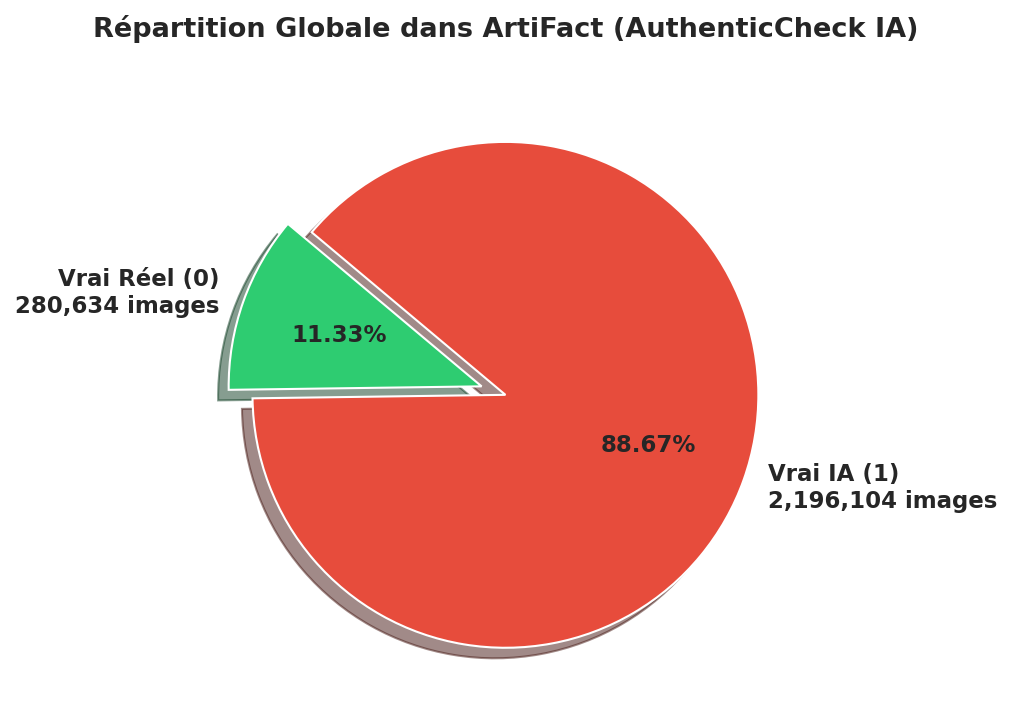

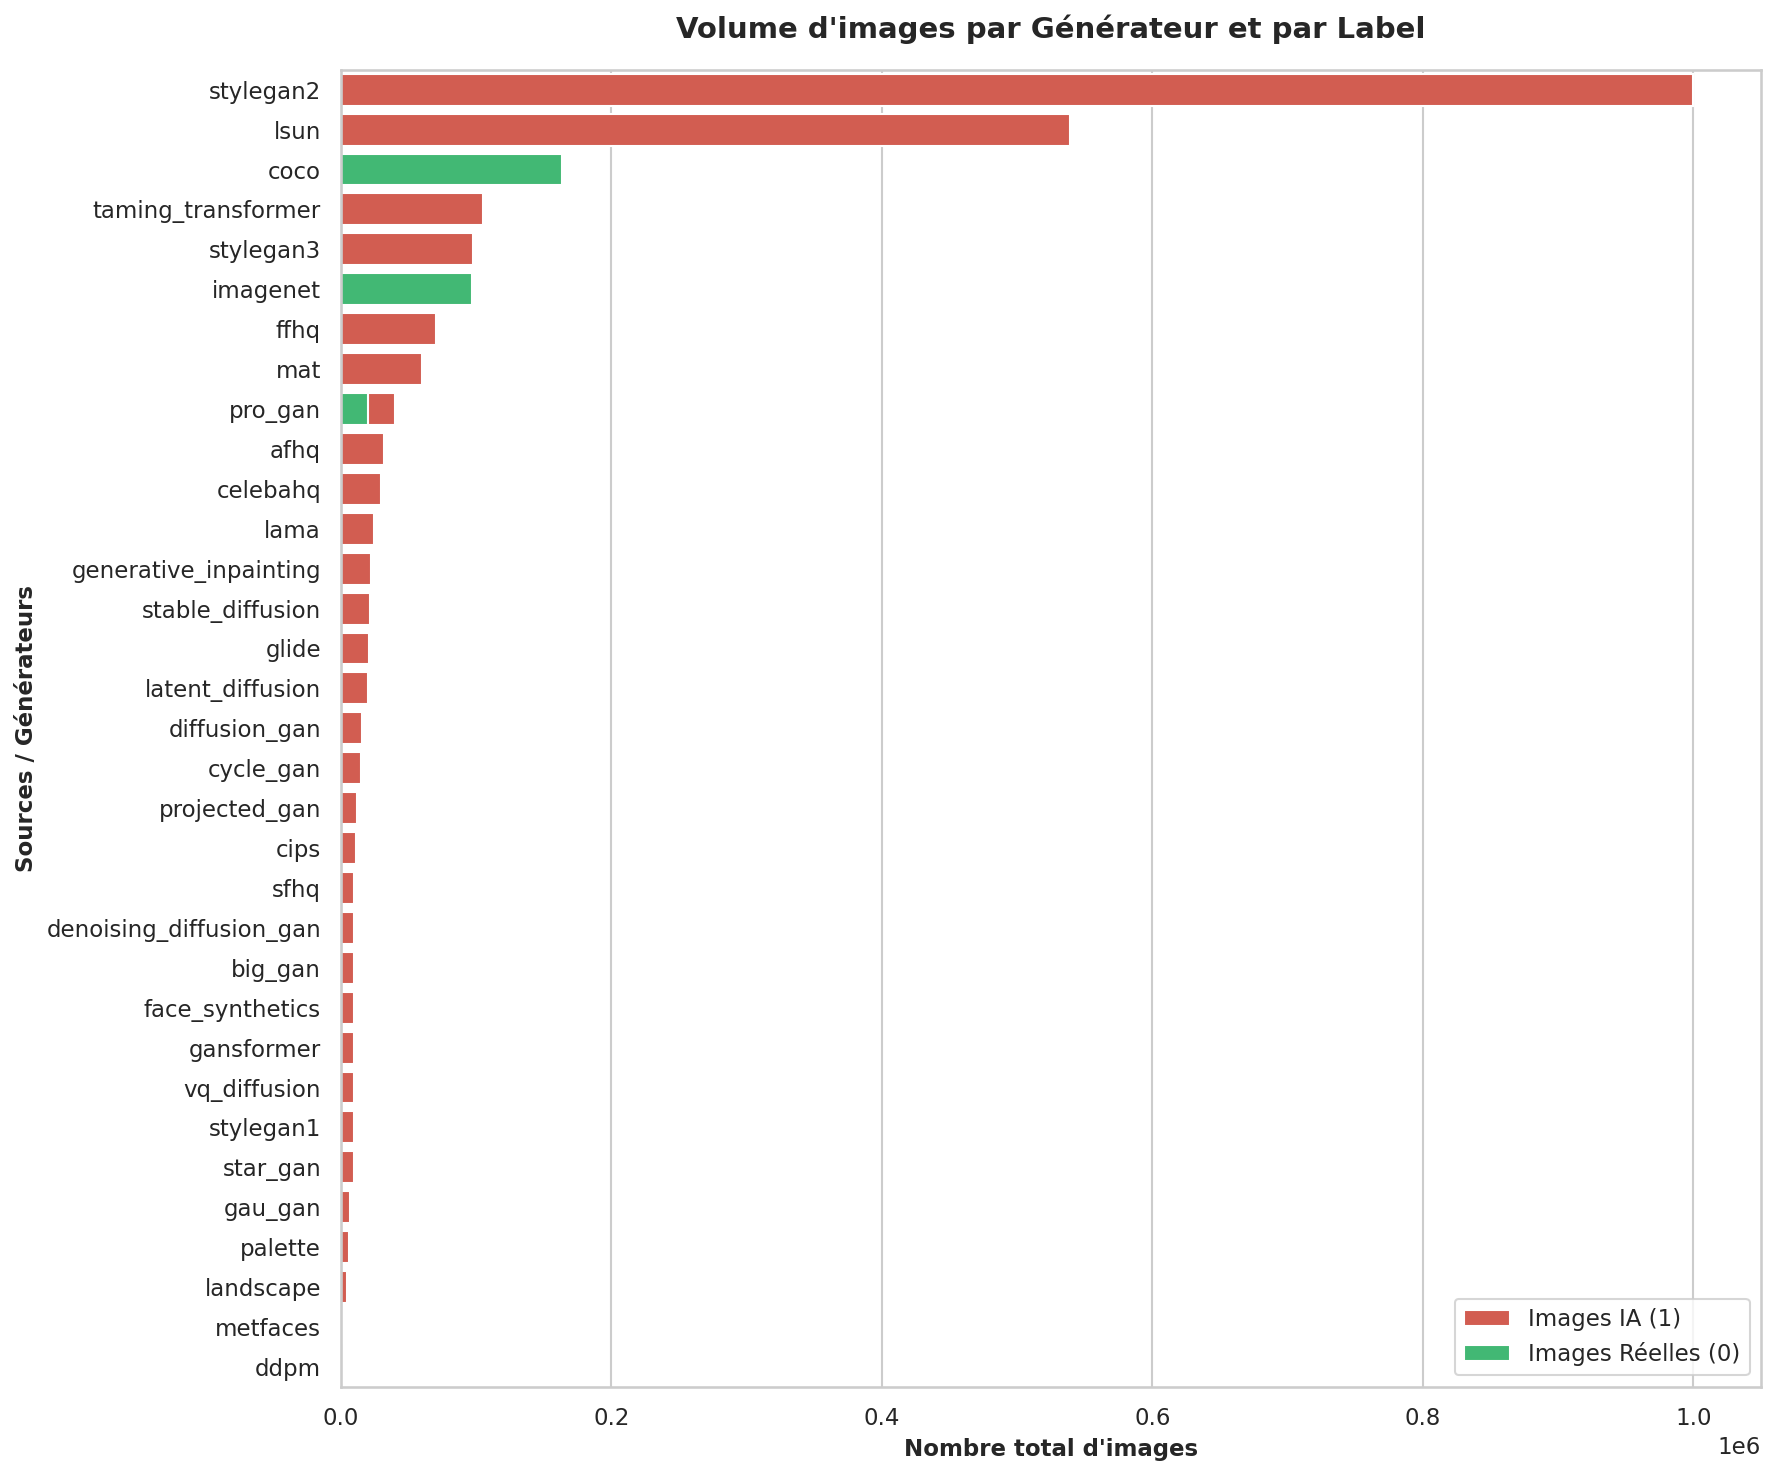

In [ ]:
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du chemin
DATASET_PATH = Path(os.path.expanduser("~/TECH2/AuthenticCheck-IA/AI DETECTION/IA detection/artifact-dataset"))

def analyze_artifact_labels(base_path):
    if not base_path.exists():
        print(f" Erreur : Le chemin {base_path} n'existe pas.")
        return None, 0, 0

    print(f"🔍 Début de l'analyse de la dataset ArtiFact dans : {base_path}\n")
    
    summary_data = []
    total_reals = 0
    total_fakes = 0

    # Liste des sous-dossiers (générateurs)
    generators = [d for d in base_path.iterdir() if d.is_dir()]
    
    for gen_dir in sorted(generators):
        gen_name = gen_dir.name
        csv_path = gen_dir / "metadata.csv"
        
        if not csv_path.exists():
            continue
            
        try:
            df = pd.read_csv(csv_path)
            reals = 0
            fakes = 0
            
            # Application des règles strictes de labellisation
            if gen_name in ["imagenet", "coco"]:
                reals = len(df[df['target'] == 0])
                fakes = len(df[df['target'] == 1])
            elif "pro_gan" in gen_name:
                reals = len(df[df['target'] == 0])
                fakes = len(df[df['target'] == 1])
            else:
                fakes = len(df)
                reals = 0

            summary_data.append({
                "Générateur": gen_name,
                "Total CSV": len(df),
                "Vrai Réel (0)": reals,
                "Vrai IA (1)": fakes
            })
            
            total_reals += reals
            total_fakes += fakes

        except Exception as e:
            print(f" Erreur lors de la lecture de {csv_path} : {e}")

    summary_df = pd.DataFrame(summary_data)
    
    # Affichage des résultats textuels
    print("\n### RÉSULTATS DU COMPTAGE PAR SOURCE ET LABEL\n")
    print(summary_df.to_markdown(index=False))
    print("\n---")
    print("###  TOTAUX GLOBAUX RECALCULÉS")
    print(f"*  **Total Images Réelles (0)** : {total_reals:,}")
    print(f"*  **Total Images IA / Fake (1)** : {total_fakes:,}")
    print(f"*  **Total Général Évalué** : {total_reals + total_fakes:,}")
    
    ratio_real = (total_reals / (total_reals + total_fakes)) * 100
    print(f"\n **Analyse de distribution** : Les images réelles représentent **{ratio_real:.2f}%** de la dataset.\n")
    
    # CRUCIAL : On retourne les variables pour qu'elles sortent de la fonction
    return summary_df, total_reals, total_fakes

# --- EXÉCUTION DE L'ANALYSE ---
if __name__ == "__main__":
    # On récupère les données de la fonction dans des variables globales
    summary_df, total_reals, total_fakes = analyze_artifact_labels(DATASET_PATH)

    # --- GÉNÉRATION DES VISUELS COLORÉS ---
    if summary_df is not None:
        print(" Génération des graphiques haute résolution...")
        sns.set_theme(style="whitegrid")
        plt.rcParams['figure.dpi'] = 150  # Haute netteté d'affichage
        colors_binary = ['#2ecc71', '#e74c3c']  # Vert pour Réel, Rouge pour IA

        # Graphique 1 : Camembert Global
        labels_pie = [f'Vrai Réel (0)\n{total_reals:,} images', f'Vrai IA (1)\n{total_fakes:,} images']
        sizes_pie = [total_reals, total_fakes]

        plt.figure(figsize=(7, 5))
        plt.pie(
            sizes_pie, 
            labels=labels_pie, 
            colors=colors_binary,
            autopct='%1.2f%%', 
            startangle=140, 
            explode=(0.1, 0),
            textprops={'fontsize': 11, 'weight': 'bold'},
            shadow=True
        )
        plt.title("Répartition Globale dans ArtiFact (AuthenticCheck IA)", fontsize=13, weight='bold', pad=20)
        plt.tight_layout()
        plt.show()

        # Graphique 2 : Histogramme par Générateur
        summary_df_sorted = summary_df.sort_values(by="Total CSV", ascending=False)

        plt.figure(figsize=(12, 10))
        sns.barplot(
            x="Total CSV", 
            y="Générateur", 
            data=summary_df_sorted, 
            label="Images IA (1)", 
            color="#e74c3c"
        )
        sns.barplot(
            x="Vrai Réel (0)", 
            y="Générateur", 
            data=summary_df_sorted, 
            label="Images Réelles (0)", 
            color="#2ecc71"
        )

        plt.title("Volume d'images par Générateur et par Label", fontsize=14, weight='bold', pad=15)
        plt.xlabel("Nombre total d'images", fontsize=11, weight='bold')
        plt.ylabel("Sources / Générateurs", fontsize=11, weight='bold')
        plt.legend(loc="lower right", fontsize=11, frameon=True)
        plt.tight_layout()
        plt.show()

**RESULTAT**
Du décompte de chaque image dans le ipynb, on remarque que la dataset Artifact possède un déséquilibre considérable au niveau des images réél et des fausse image. 88,67% pour 11,33%

**VERIFICATION DES FORMATS DE CHAQUE IMAGE**

🔍 Analyse des formats d'images dans : /home/mouhtar/TECH2/AuthenticCheck-IA/AI DETECTION/IA detection/artifact-dataset
⏳ Lecture des métadonnées en cours (extraction des extensions)...

### 📊 TABLEAU DE RÉPARTITION DES FORMATS DÉTECTÉS

| Extension   |   Nombre |
|:------------|---------:|
| .jpg        |  2496738 |

---
🎨 Génération du graphique de distribution des formats...


/tmp/ipykernel_10780/543073254.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


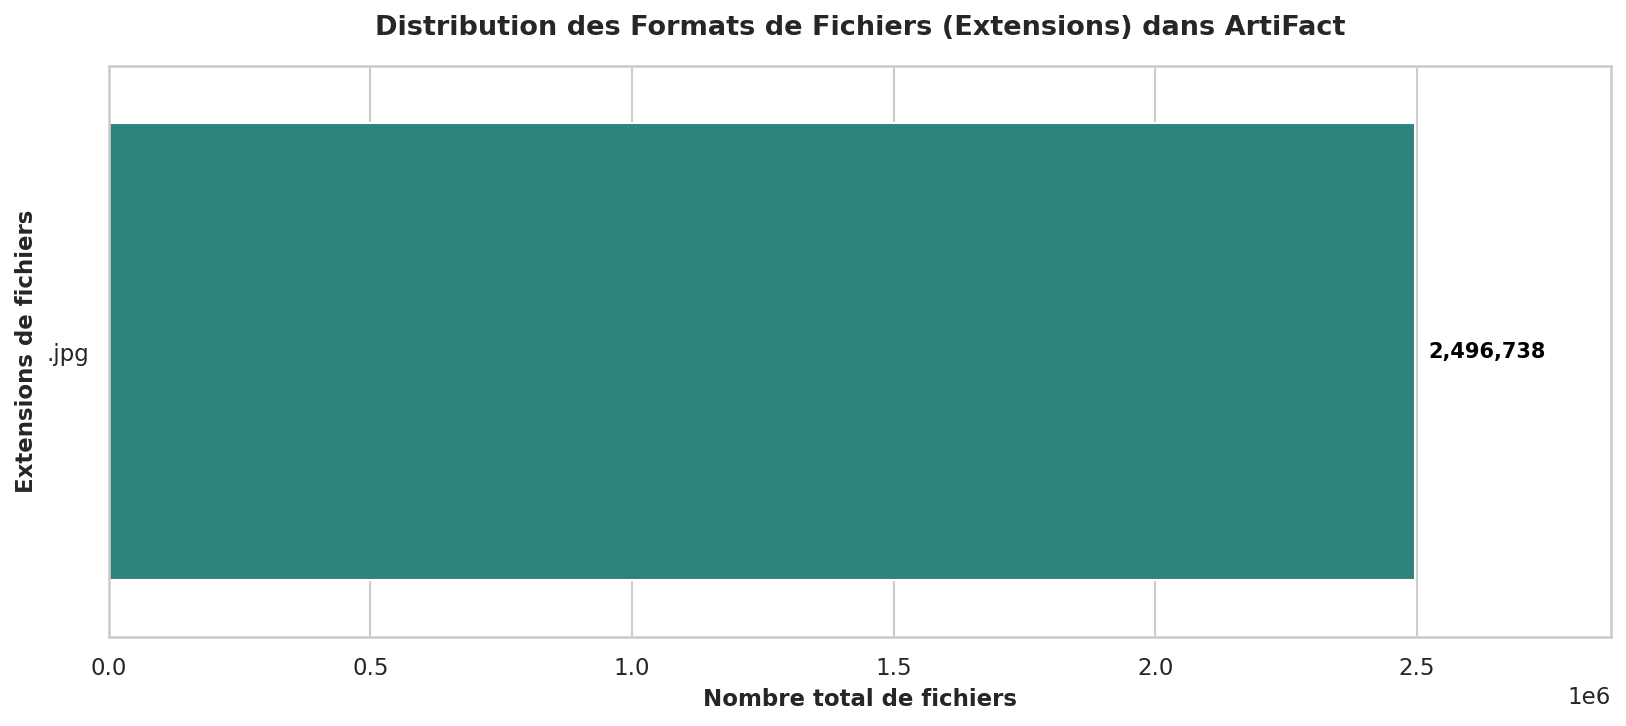

In [1]:
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configuration du chemin vers artifact-dataset
DATASET_PATH = Path(os.path.expanduser("~/TECH2/AuthenticCheck-IA/AI DETECTION/IA detection/artifact-dataset"))

def analyze_image_formats(base_path):
    if not base_path.exists():
        print(f"❌ Erreur : Le chemin {base_path} n'existe pas.")
        return
    
    print(f"🔍 Analyse des formats d'images dans : {base_path}")
    print("⏳ Lecture des métadonnées en cours (extraction des extensions)...")
    
    extensions_counter = Counter()
    generators = [d for d in base_path.iterdir() if d.is_dir()]
    
    for gen_dir in sorted(generators):
        gen_name = gen_dir.name
        csv_path = gen_dir / "metadata.csv"
        
        if not csv_path.exists():
            continue
            
        try:
            df = pd.read_csv(csv_path)
            
            # Détection automatique de la colonne contenant le chemin ou le nom du fichier
            path_col = None
            for col in df.columns:
                if col.lower() in ['path', 'filename', 'image_path', 'image', 'file']:
                    path_col = col
                    break
            
            # Si aucune colonne classique n'est trouvée, on cherche une colonne contenant des extensions connues
            if path_col is None:
                for col in df.columns:
                    if df[col].astype(str).str.contains(r'\.(jpg|jpeg|png|webp|bmp|gif)', case=False, na=False).any():
                        path_col = col
                        break
                        
            if path_col and path_col in df.columns:
                # Extraction de l'extension (ex: .jpg, .PNG) en conservant la casse d'origine
                exts = df[path_col].dropna().astype(str).apply(lambda x: Path(x).suffix)
                extensions_counter.update(exts)
            else:
                print(f"⚠️ Colonne de chemin introuvable pour le générateur : {gen_name}")
                
        except Exception as e:
            print(f"❌ Erreur lors du traitement de {gen_name} : {e}")
            
    # Conversion des résultats en DataFrame propre
    format_df = pd.DataFrame(extensions_counter.items(), columns=['Extension', 'Nombre'])
    
    # Nettoyage des extensions vides si présentes
    format_df['Extension'] = format_df['Extension'].replace('', '.sans_extension')
    format_df = format_df.sort_values(by='Nombre', ascending=False).reset_index(drop=True)
    
    # Affichage du tableau de synthèse textuel
    print("\n### 📊 TABLEAU DE RÉPARTITION DES FORMATS DÉTECTÉS\n")
    print(format_df.to_markdown(index=False))
    print("\n---")
    
    # --- GÉNÉRATION DU VISUEL GRAPHIQUE COLORÉ ---
    print("🎨 Génération du graphique de distribution des formats...")
    sns.set_theme(style="whitegrid")
    plt.rcParams['figure.dpi'] = 150  # Haute résolution d'affichage
    
    # Création d'une palette de couleurs dégradée et vive
    palette = sns.color_palette("viridis", len(format_df))
    
    plt.figure(figsize=(11, 5))
    barplot = sns.barplot(
        x="Nombre", 
        y="Extension", 
        data=format_df, 
        palette=palette
    )
    
    # Ajout des étiquettes de valeurs chiffrées précises au bout de chaque barre horizontale
    max_val = format_df['Nombre'].max()
    for index, row in format_df.iterrows():
        barplot.text(
            row['Nombre'] + (max_val * 0.01),  # Petit décalage à droite de la barre
            index, 
            f"{row['Nombre']:,}", 
            color='black', 
            ha="left", 
            va="center", 
            fontweight='bold', 
            fontsize=10
        )
        
    plt.title("Distribution des Formats de Fichiers (Extensions) dans ArtiFact", fontsize=13, weight='bold', pad=15)
    plt.xlabel("Nombre total de fichiers", fontsize=11, weight='bold')
    plt.ylabel("Extensions de fichiers", fontsize=11, weight='bold')
    plt.xlim(0, max_val * 1.15)  # Donne de l'espace à droite pour afficher les étiquettes de texte
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_image_formats(DATASET_PATH)

**RESULTAT**
De l'analyse des 2,4 millions d'image que dispose notre dataset on remarque que la totalité des images sont en format jpg. Ce qui rend la dataset plus légère et plus facille à manipuler

**ANALYSE DES CANNAUX DE COULEURS**
Les images doivent posséder trois canneaux de couleurs (Rouge, Vert, Bleu) ils doivent etre (224, 224, 3) et non (224, 224, 1)


[INFO] Génération de la visualisation graphique...


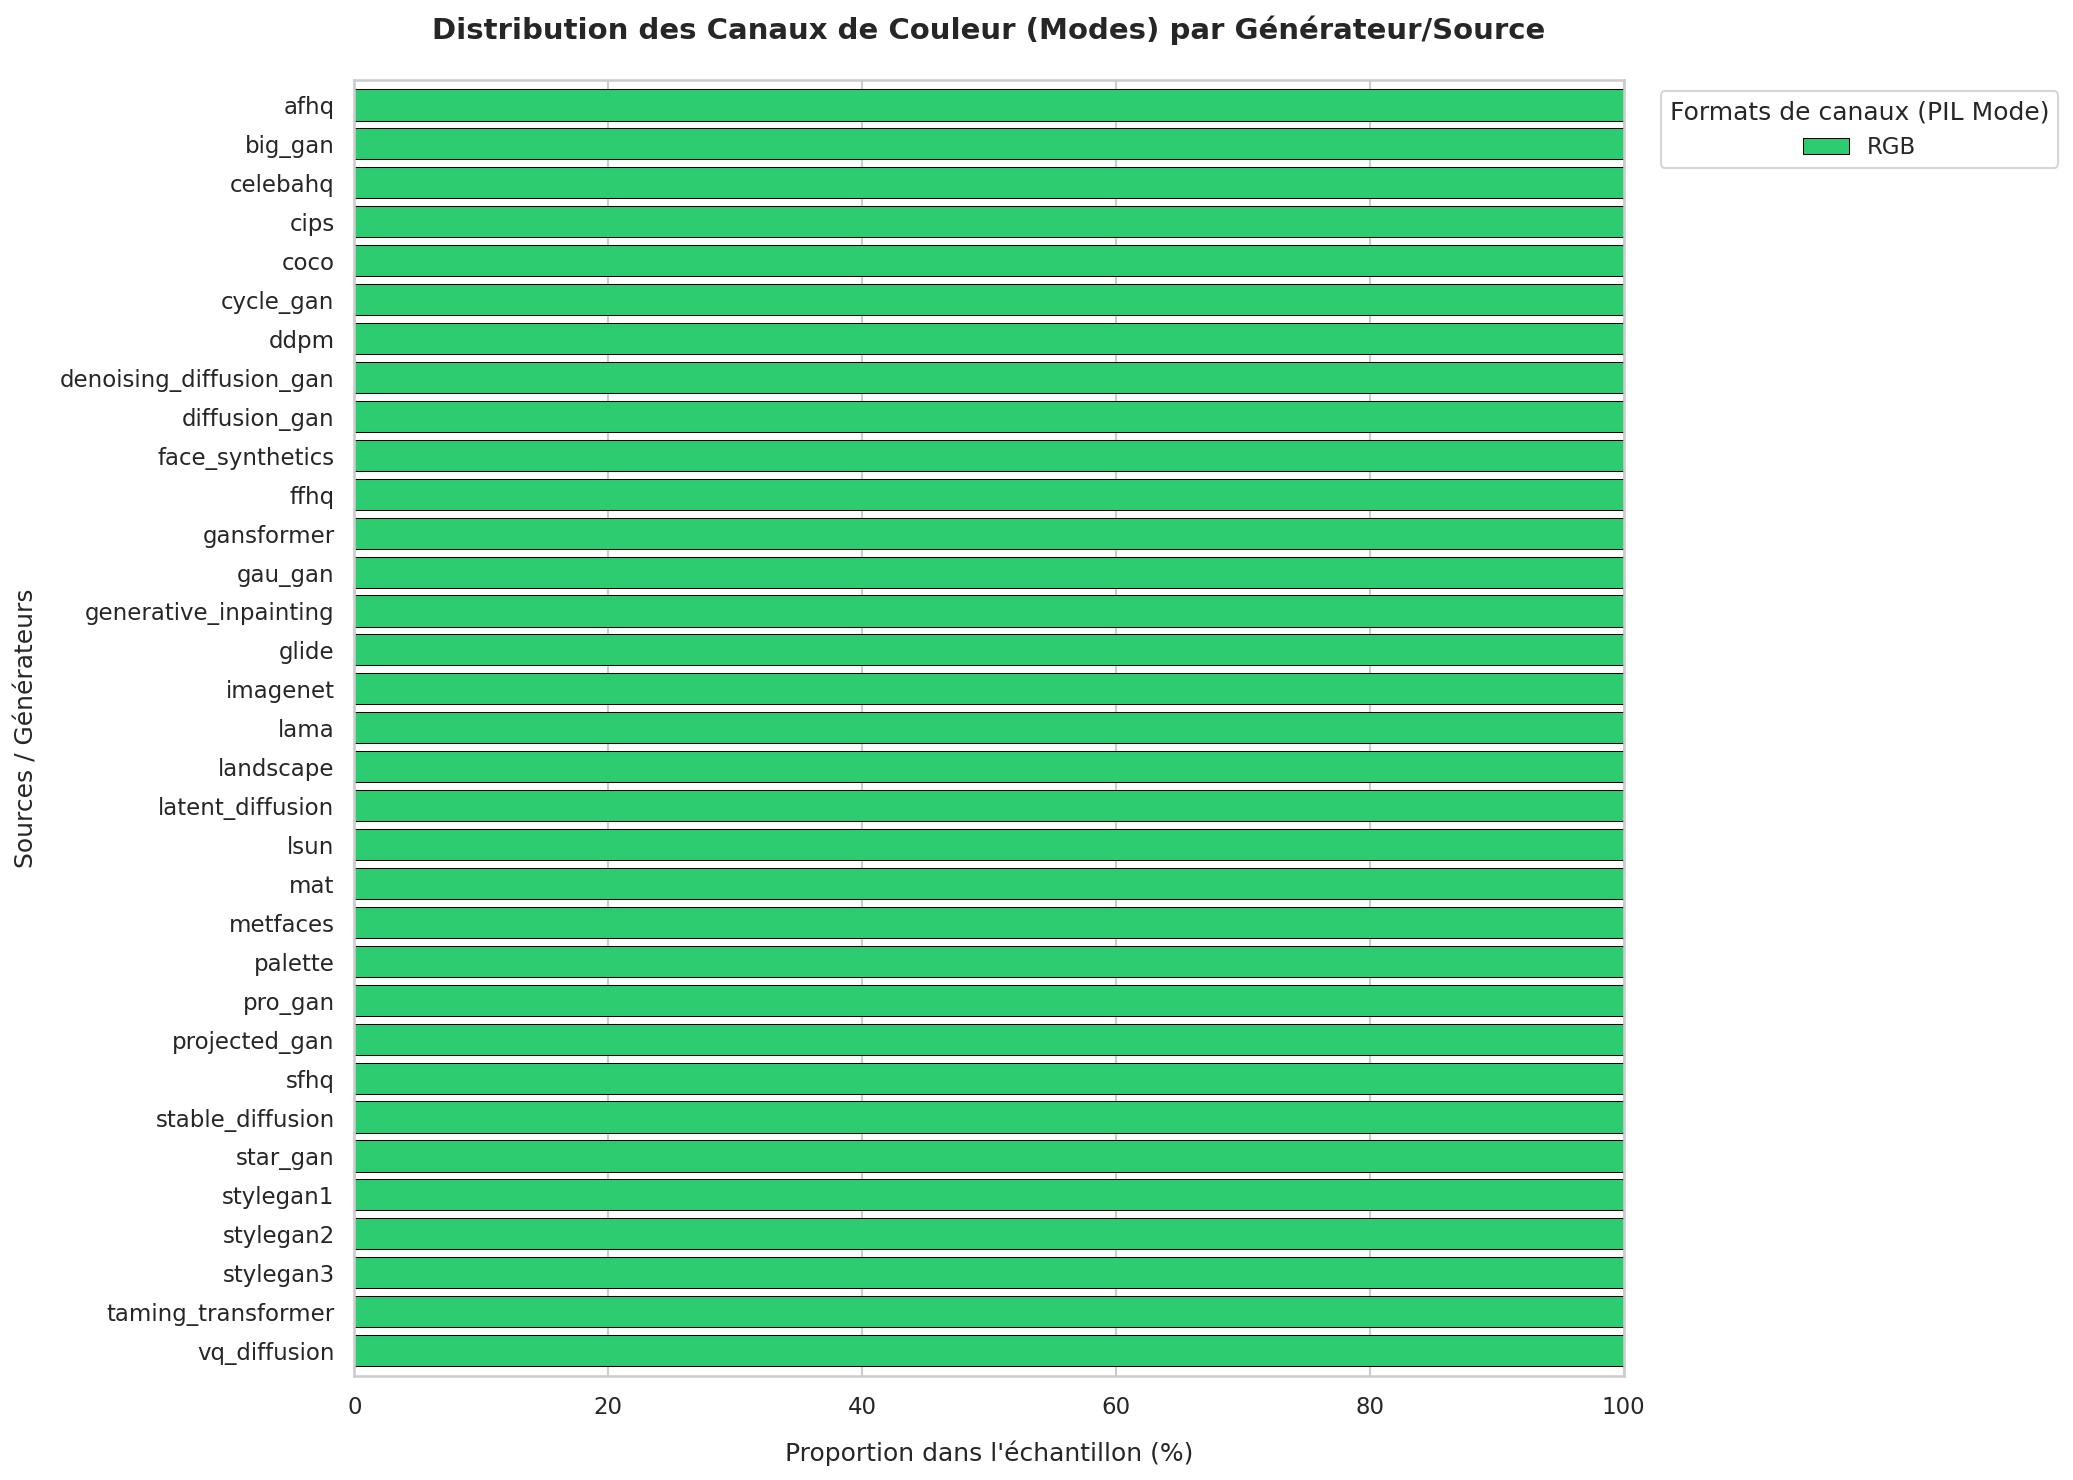

In [4]:
import os
import random
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# ==============================================================================
# CONFIGURATION
# ==============================================================================
DATASET_DIR = "IA detection/artifact-dataset"
SAMPLE_SIZE_PER_GEN = 1000  # Taille de l'échantillon par générateur

# Configuration du style graphique (propre et lisible pour une présentation)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ==============================================================================
# 1. COLLECTE ET ANALYSE DES DONNÉES
# ==============================================================================
results = []

if not os.path.exists(DATASET_DIR):
    print(f"[ERREUR] Le dossier '{DATASET_DIR}' est introuvable.")
else:
    generators = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]
    
    for gen in generators:
        gen_path = os.path.join(DATASET_DIR, gen)
        all_images = []
        for root, _, files in os.walk(gen_path):
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_images.append(os.path.join(root, f))
        
        total_images = len(all_images)
        if total_images == 0:
            continue
            
        sample_size = min(SAMPLE_SIZE_PER_GEN, total_images)
        sampled_images = random.sample(all_images, sample_size)
        modes_counter = Counter()
        
        for img_path in tqdm(sampled_images, desc=f"Analyse {gen}", leave=False):
            try:
                with Image.open(img_path) as img:
                    modes_counter[img.mode] += 1
            except Exception:
                modes_counter["FICHIER_CORROMPU"] += 1
        
        for mode, count in modes_counter.items():
            results.append({
                "Générateur": gen,
                "Mode": mode,
                "Proportion (%)": round((count / sample_size) * 100, 2)
            })

    # Création du DataFrame
    df_results = pd.DataFrame(results)

    # ==============================================================================
    # 2. GÉNÉRATION DU GRAPHIQUE
    # ==============================================================================
    print("\n[INFO] Génération de la visualisation graphique...")
    
    # Pivot de la table pour avoir les formats (RGB, L, RGBA) en colonnes
    df_pivot = df_results.pivot(index="Générateur", columns="Mode", values="Proportion (%)").fillna(0)
    
    # Tri des générateurs par ordre alphabétique ou par proportion de RGB pour aligner le visuel
    df_pivot = df_pivot.sort_index(ascending=False)
    
    # Création de la figure
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Palette de couleurs explicites (par exemple : Bleu pour RGB, Orange pour le N&B, Rouge pour les erreurs)
    colors = {
        'RGB': '#2ecc71',           # Vert (OK)
        'RGBA': '#3498db',          # Bleu (Transparence à convertir)
        'L': '#f1c40f',             # Jaune/Orange (Niveaux de gris à convertir)
        'FICHIER_CORROMPU': '#e74c3c' # Rouge (Alerte corruption)
    }
    # On applique les couleurs dispo dans notre dataset
    current_colors = [colors.get(col, '#95a5a6') for col in df_pivot.columns]
    
    # Dessin du graphique en barres horizontales empilées
    df_pivot.plot(
        kind='barh', 
        stacked=True, 
        ax=ax, 
        color=current_colors, 
        width=0.8,
        edgecolor='black',
        linewidth=0.5
    )
    
    # Personnalisation des axes et légendes
    ax.set_title("Distribution des Canaux de Couleur (Modes) par Générateur/Source", pad=20, fontweight='bold')
    ax.set_xlabel("Proportion dans l'échantillon (%)", labelpad=10)
    ax.set_ylabel("Sources / Générateurs", labelpad=10)
    ax.set_xlim(0, 100)
    
    # Placement de la légende en dehors du graphique pour ne pas masquer les données
    ax.legend(title="Formats de canaux (PIL Mode)", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

**RESULTAT**

On remarque que tout les images des générateur sont en format RGB

**TEST DE CORRUPTION ET D'INTÉGRITER**
Consiste à faire un script pour vérifier si aucun image n'est corrompu

[INFO] Démarrage du test d'intégrité sur 33 générateurs/sources.




ANALYSE TERMINÉE : 0 IMAGES CORROMPUES DÉTECTÉES
[RAS] Félicitations ! Aucune image corrompue n'a été détectée dans l'échantillon.

[INFO] Génération du graphique d'intégrité...


/tmp/ipykernel_10780/1064494928.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


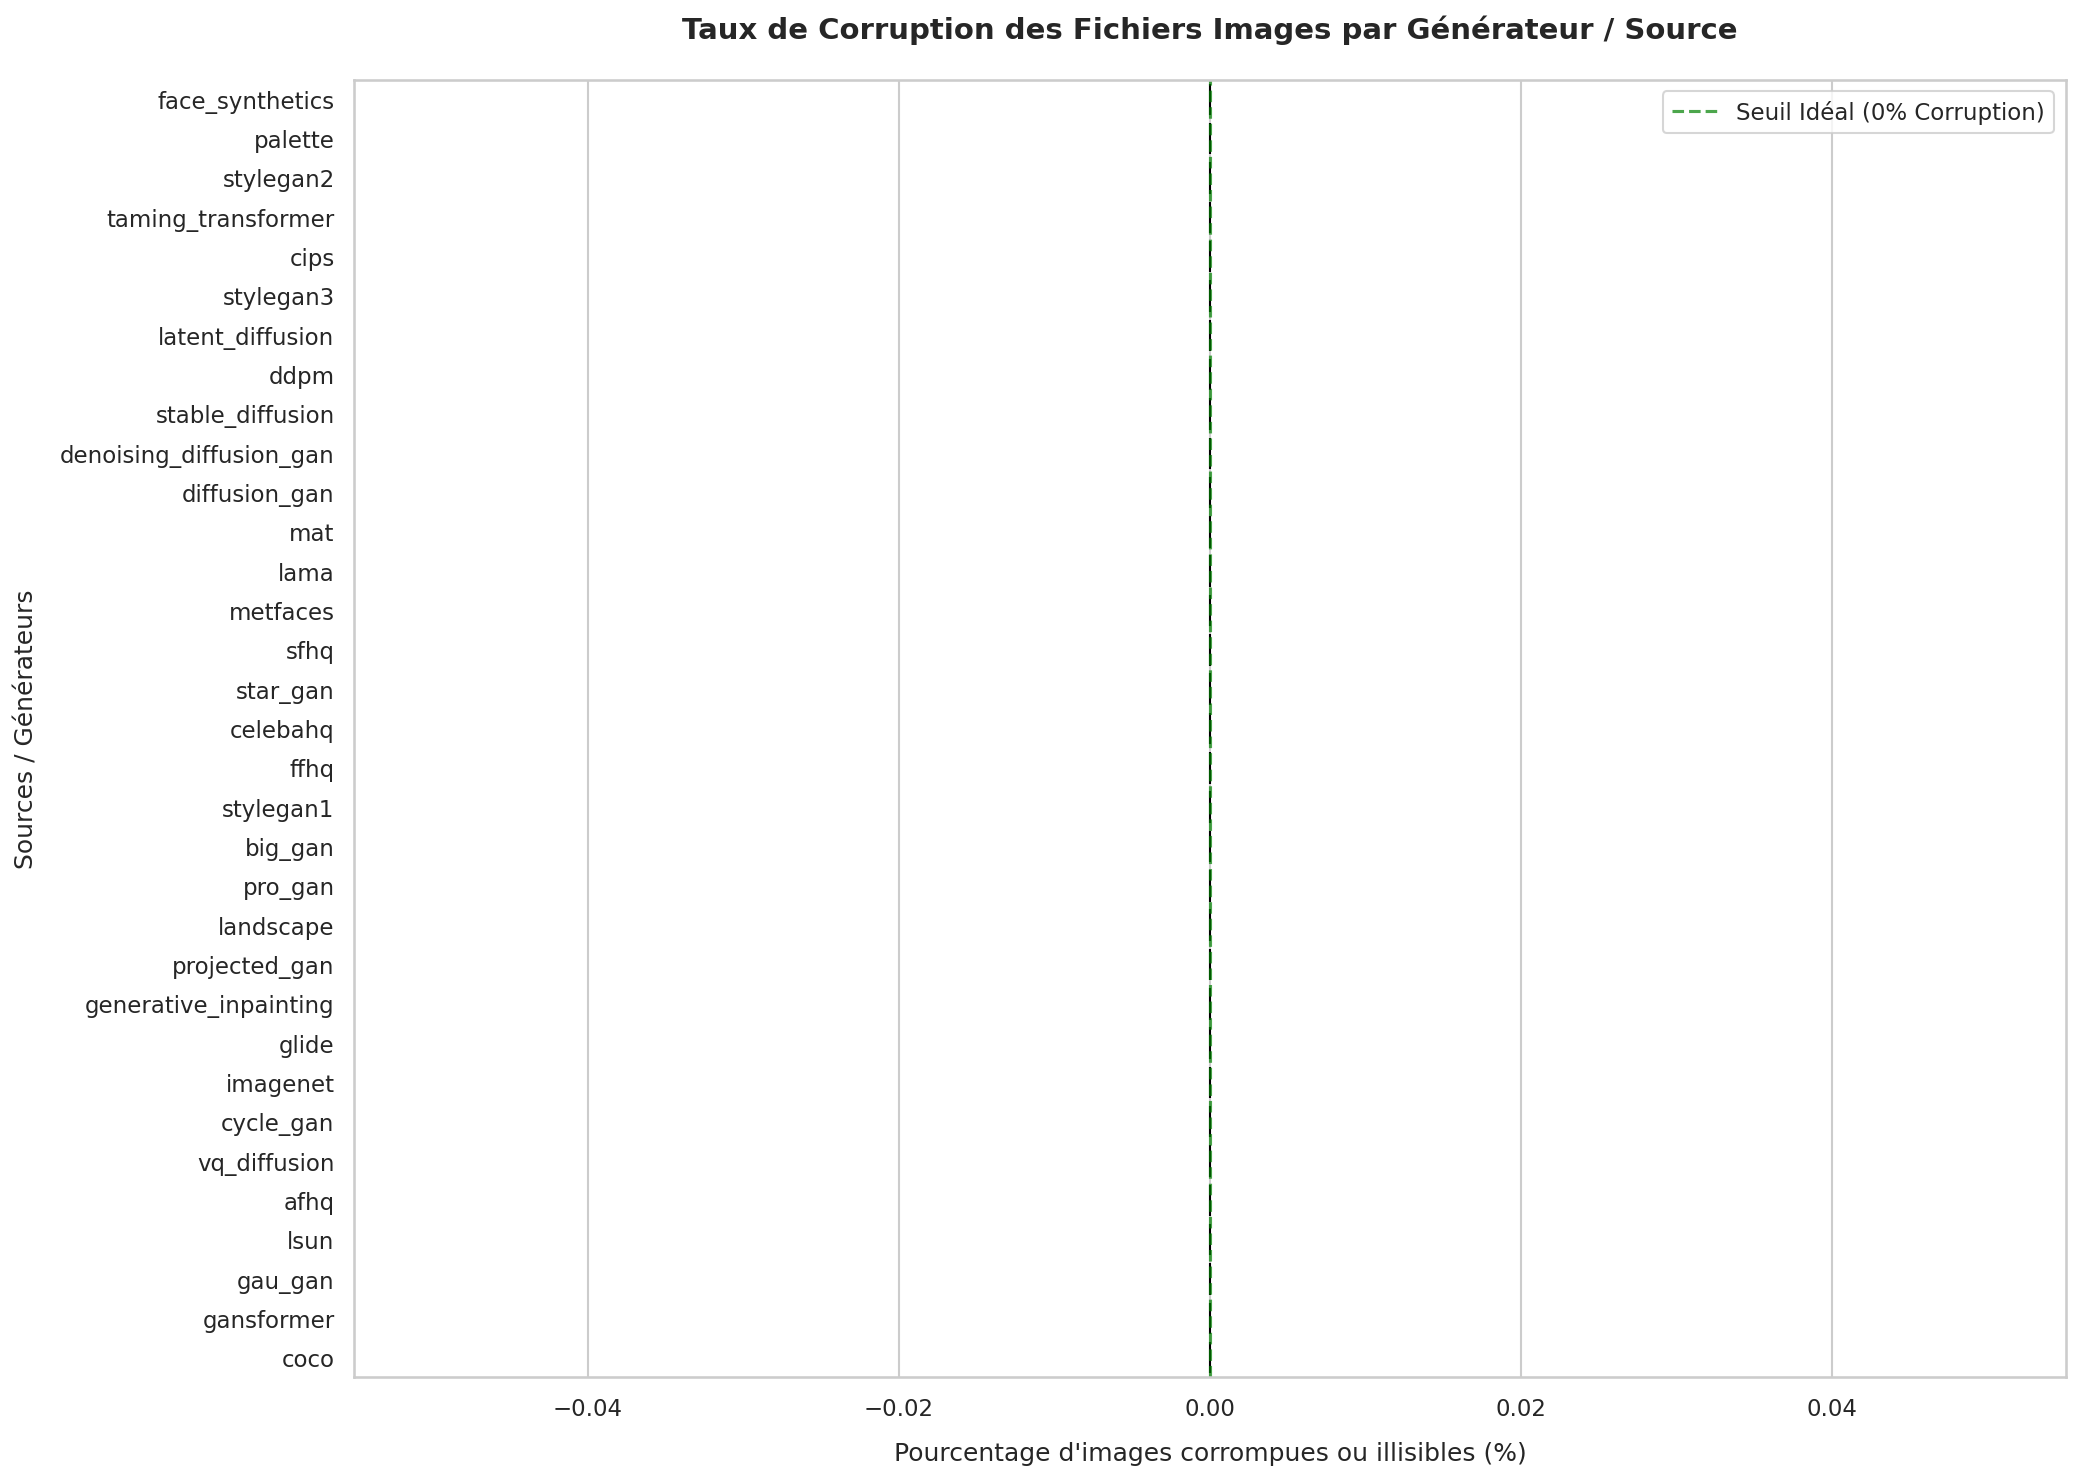

In [5]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Chemin relatif validé ensemble lors de l'étape précédente
DATASET_DIR = "IA detection/artifact-dataset" 

# Nombre d'images à tester par générateur. 
# Mettez 'None' si vous voulez scanner l'INTEGRALITÉ des 2,4 millions d'images 
# (Utile pour un nettoyage final, mais attention : cela prendra plusieurs heures !)
SAMPLE_SIZE_PER_GEN = 2000  

# Configuration du style graphique
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# ==============================================================================
# 1. SCAN D'INTÉGRITÉ ET DE CORRUPTION
# ==============================================================================
integrity_results = []

if not os.path.exists(DATASET_DIR):
    print(f"[ERREUR] Le dossier '{DATASET_DIR}' est introuvable. Vérifiez votre arborescence.")
else:
    generators = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]
    print(f"[INFO] Démarrage du test d'intégrité sur {len(generators)} générateurs/sources.\n")
    
    for gen in generators:
        gen_path = os.path.join(DATASET_DIR, gen)
        all_images = []
        
        for root, _, files in os.walk(gen_path):
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_images.append(os.path.join(root, f))
        
        total_images = len(all_images)
        if total_images == 0:
            continue
            
        # Choix de la taille de l'échantillon
        if SAMPLE_SIZE_PER_GEN is None:
            sampled_images = all_images
            sample_size = total_images
        else:
            sample_size = min(SAMPLE_SIZE_PER_GEN, total_images)
            sampled_images = random.sample(all_images, sample_size)
            
        valid_count = 0
        corrupted_count = 0
        
        for img_path in tqdm(sampled_images, desc=f"Vérification {gen}", leave=False):
            try:
                # 1. Check direct de la taille du fichier (les fichiers vides de 0 Ko)
                if os.path.getsize(img_path) == 0:
                    corrupted_count += 1
                    continue
                
                # 2. Check de la structure interne de l'image
                with Image.open(img_path) as img:
                    img.verify() # Inspecte le fichier sans charger les pixels en RAM
                valid_count += 1
                
            except Exception:
                corrupted_count += 1
                
        integrity_results.append({
            "Générateur": gen,
            "Images Valides": valid_count,
            "Images Corrompues": corrupted_count,
            "Taux de Corruption (%)": round((corrupted_count / sample_size) * 100, 3)
        })

    # Synthèse dans un DataFrame
    df_integrity = pd.DataFrame(integrity_results)
    
    # ==============================================================================
    # 2. RÉSULTATS TEXTUELS & ALERTES
    # ==============================================================================
    total_corrupted_detected = df_integrity["Images Corrompues"].sum()
    print("\n" + "="*60)
    print(f"ANALYSE TERMINÉE : {total_corrupted_detected} IMAGES CORROMPUES DÉTECTÉES")
    print("="*60)
    
    if total_corrupted_detected > 0:
        print("[ALERTE] Certains générateurs contiennent des fichiers endommagés :")
        display(df_integrity[df_integrity["Images Corrompues"] > 0].sort_values(by="Images Corrompues", ascending=False))
    else:
        print("[RAS] Félicitations ! Aucune image corrompue n'a été détectée dans l'échantillon.")

    # ==============================================================================
    # 3. VISUALISATION GRAPHIQUE
    # ==============================================================================
    print("\n[INFO] Génération du graphique d'intégrité...")
    df_plot = df_integrity.set_index("Générateur").sort_values(by="Taux de Corruption (%)", ascending=True)
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Graphique en barres empilées (Proportion Valide vs Corrompu)
    # Pour que ce soit visible même si le taux de corruption est très faible (<1%), 
    # on affiche directement le Taux de Corruption sur un axe, ou le décompte.
    # Ici, on trace le Taux de Corruption (%) par générateur pour cibler les dossiers problématiques.
    
    sns.barplot(
        x="Taux de Corruption (%)", 
        y="Générateur", 
        data=df_integrity.sort_values(by="Taux de Corruption (%)", ascending=False),
        ax=ax,
        palette="Reds_r",
        edgecolor="black"
    )
    
    ax.set_title("Taux de Corruption des Fichiers Images par Générateur / Source", pad=20, fontweight='bold')
    ax.set_xlabel("Pourcentage d'images corrompues ou illisibles (%)", labelpad=10)
    ax.set_ylabel("Sources / Générateurs", labelpad=10)
    
    # Ajout d'une ligne rouge critique si le taux dépasse 0%
    ax.axvline(x=0, color='green', linestyle='--', alpha=0.7, label="Seuil Idéal (0% Corruption)")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

**RESULTAT**
De l'analyse on remarque qu'il n'y a pas d'image corrompu dans les générateurs .